# Full B-747 engine-out trim hold: ET-DHP lateral FTC + longitudinal hold

This notebook demonstrates a complete single-engine-out control scheme for the nonlinear Boeing 747-100 model. At $t = 10$ s the left outer engine fails; the simulation then continues to $t = 300$ s so steady-state errors are visible. The goal is to keep the aircraft close to the original cruise trim point:

* true airspeed $V$ unchanged;
* altitude $h$ unchanged;
* pitch $\theta$ unchanged;
* roll $\phi$ unchanged;
* yaw/heading $\psi$ unchanged.

The fault-tolerant part is the lateral-directional **ET-DHP** controller. It learns the rudder/aileron compensation for the asymmetric-thrust yawing moment without using an engine-effectiveness matrix or a fault-tolerant allocator. A longitudinal trim-hold loop commands elevator and throttle; it includes an engine-out throttle feed-forward term so altitude does not drift before the speed loop reacts.

## Control-engineering structure

| Block | Inputs | Outputs | Purpose |
|---|---|---|---|
| Longitudinal trim hold | $V-h-\theta-q$ errors | $\delta_e,\delta_T$ | Keep speed, altitude and pitch at the cruise trim. |
| ET-DHP lateral FTC | $e_\psi,\int e_\psi dt,r,\phi,\int\phi dt,p$ | $\delta_a,\delta_r$ | Reject the asymmetric-thrust yaw/roll disturbance. |
| B-747 nonlinear plant | $[\delta_e,\delta_a,\delta_r,\delta_T]$ | 12-state 6-DoF response | Engine #1 is failed by the damage subsystem. |

The requirement "do not change" is implemented as explicit engineering tolerances in the final evaluation cell. A zero transient is physically impossible because the engine failure instantaneously removes thrust and creates a yawing moment; the controller must reject that disturbance over the following seconds.


## 1. Imports and simulation settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math

import matplotlib.pyplot as plt
import numpy as np

from tensoraerospace.aerospacemodel.b747.nonlinear import B747Configuration, trim
from tensoraerospace.aerospacemodel.b747.nonlinear.engine import JT9DEngine
from tensoraerospace.aerospacemodel.b747.nonlinear.params import (
    default_parameters, isa_speed_of_sound_ft_s,
)
from tensoraerospace.aerospacemodel.b747.nonlinear.damage import LEFT_OUTER_ENGINE_FAILURE
from tensoraerospace.envs.b747_nonlinear import NonlinearB747Env
from tensoraerospace.agent.et_dhp import ETDHPAgent, ETDHPConfig

DT = 0.05
TOTAL_TIME = 300.0
TRAIN_TIME = 60.0
DAMAGE_TIME = 10.0
N_EP = int(TOTAL_TIME / DT)
N_TRAIN = int(TRAIN_TIME / DT)
DAMAGE_STEP = int(DAMAGE_TIME / DT)

V_REF_FT_S = 674.0
ALT_REF_FT = 20_000.0
PSI_REF_DEG = 0.0

# Final closed-loop acceptance bands.
SPEED_HOLD_BAND_FT_S = 1.0
ALT_HOLD_BAND_FT = 1.5
YAW_HOLD_BAND_DEG = 0.05
ROLL_HOLD_BAND_DEG = 0.12
PITCH_HOLD_BAND_DEG = 0.05

# Lateral ET-DHP integral scaling.
I_LAT_SCALE = 0.1
I_LAT_LIMIT_DEG_S = 30.0

# Longitudinal trim-hold gains. Signs match the B-747 model convention:
# positive elevator is nose-down, throttle is in [0, 1].
K_THR_V = 0.010
K_THR_IV = 0.0015
K_ALT_THETA = 0.0012
K_ALT_I_THETA = 4.0e-5
K_HDOT_THETA = 0.025
K_SPEED_THETA = 0.0
K_THETA_ELEV = 0.70
K_Q_ELEV = 0.70
INT_V_LIMIT = 800.0
INT_H_LIMIT = 2_000.0
THETA_CMD_LIMIT_DEG = 4.0
ELEVATOR_DELTA_LIMIT_DEG = 6.0

# Command smoothing: avoid visually noisy elevator/throttle commands.
HDOT_FILTER_ALPHA = 0.12
ELEVATOR_RATE_LIMIT_DEG_S = 0.7
THROTTLE_RATE_LIMIT_PER_S = 0.12
ENGINE_OUT_THROTTLE_FF_GAIN = 1.05
ENGINE_OUT_THROTTLE_FF_TAU_S = 0.0

print(f"Evaluation length: {TOTAL_TIME:.0f} s ({N_EP} steps @ dt={DT}s)")
print(f"Lateral ET-DHP training episode: {TRAIN_TIME:.0f} s ({N_TRAIN} steps)")
print(f"Damage trigger: t = {DAMAGE_TIME:.0f} s (step {DAMAGE_STEP})")
print("Final tolerances:")
print(f"  |V - V0| <= {SPEED_HOLD_BAND_FT_S:.1f} ft/s")
print(f"  |h - h0| <= {ALT_HOLD_BAND_FT:.1f} ft")
print(f"  |psi| <= {YAW_HOLD_BAND_DEG:.2f} deg, |phi| <= {ROLL_HOLD_BAND_DEG:.2f} deg, "
      f"|theta-theta0| <= {PITCH_HOLD_BAND_DEG:.2f} deg")


Evaluation length: 300 s (6000 steps @ dt=0.05s)
Lateral ET-DHP training episode: 60 s (1200 steps)
Damage trigger: t = 10 s (step 200)
Final tolerances:
  |V - V0| <= 1.0 ft/s
  |h - h0| <= 1.5 ft
  |psi| <= 0.05 deg, |phi| <= 0.12 deg, |theta-theta0| <= 0.05 deg


## 2. Cruise trim point

The plant starts from a healthy four-engine cruise trim at FL200 and $V \approx 674$ ft/s. Elevator and throttle trim are used as the baseline commands. After the engine fails, the longitudinal trim-hold loop is allowed to move elevator and throttle; the lateral ET-DHP actor moves only aileron and rudder.


In [2]:
trim_result = trim(altitude_ft=ALT_REF_FT, V_ft_s=V_REF_FT_S,
                   config=B747Configuration.NOMINAL)
assert trim_result.converged

delta_e_trim_rad = float(trim_result.elevator_rad)
throttle_trim = float(trim_result.throttle)
theta_ref_deg = math.degrees(trim_result.theta_rad)
throttle_engine_out_ff = min(throttle_trim * 4.0 / 3.0, 1.0)
engine_params = default_parameters(B747Configuration.NOMINAL)
engine_model = JT9DEngine(
    n_engines=4,
    sls_thrust_per_engine_lb=engine_params.engine_thrust_max_lb / 4.0,
    idle_frac=engine_params.engine_idle_frac,
    spool_tau_s=engine_params.engine_tau_s,
)

print(f"Trim @ FL200, V={V_REF_FT_S:.0f} ft/s, NOMINAL:")
print(f"  alpha = theta = {theta_ref_deg:+.3f} deg")
print(f"  delta_e_trim  = {math.degrees(delta_e_trim_rad):+.3f} deg")
print(f"  throttle_trim = {throttle_trim:.4f}")
print(f"  one-engine-out throttle estimate = {throttle_engine_out_ff:.4f}")
print(f"  feed-forward throttle target = "
      f"{throttle_trim + ENGINE_OUT_THROTTLE_FF_GAIN * (throttle_engine_out_ff - throttle_trim):.4f}")


Trim @ FL200, V=674 ft/s, NOMINAL:
  alpha = theta = +3.603 deg
  delta_e_trim  = -0.722 deg
  throttle_trim = 0.5549
  one-engine-out throttle estimate = 0.7399
  feed-forward throttle target = 0.7492


## 3. State transforms and command composition

The lateral ET-DHP state is

$$
\tilde x_{lat}=[e_\psi,\;0.1i_\psi,\;r,\;\phi,\;0.1i_\phi,\;p]^T,
$$

where $i_\psi=\int e_\psi dt$ and $i_\phi=\int\phi dt$ are clipped anti-windup states. The roll integral is what removes the small bank offset that appeared in the yaw-only version of the example.

The longitudinal trim-hold loop uses measured $V,h,\theta,q$ to command elevator and throttle around the healthy trim. It is intentionally kept explicit and short so a control engineer can see the signs, saturations and feedback paths.


In [3]:
def wrap_deg(angle_deg):
    """Wrap an angle to [-180, 180) deg."""
    return (float(angle_deg) + 180.0) % 360.0 - 180.0


def true_airspeed_ft_s(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    return float(np.linalg.norm(obs[:3]))


def altitude_ft(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    return float(-obs[11])


def yaw_error_deg(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    return wrap_deg(math.degrees(obs[8]) - PSI_REF_DEG)


def roll_deg(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    return math.degrees(obs[6])


def pitch_error_deg(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    return math.degrees(obs[7]) - theta_ref_deg


def update_lateral_integrals(lat_integrals_deg_s, obs):
    errors = np.array([yaw_error_deg(obs), roll_deg(obs)], dtype=np.float64)
    next_integrals = np.asarray(lat_integrals_deg_s, dtype=np.float64) + errors * DT
    return np.clip(next_integrals, -I_LAT_LIMIT_DEG_S, I_LAT_LIMIT_DEG_S)


def lateral_state_transform(obs, ref, time_step):
    """Build [e_psi, scaled int e_psi, r, phi, scaled int phi, p]."""
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    if ref is None:
        lat_integrals = np.zeros(2, dtype=np.float64)
    else:
        lat_integrals = np.asarray(ref, dtype=np.float64).reshape(-1)[:2]
    return np.array([
        yaw_error_deg(obs),
        I_LAT_SCALE * lat_integrals[0],
        math.degrees(obs[5]),
        roll_deg(obs),
        I_LAT_SCALE * lat_integrals[1],
        math.degrees(obs[3]),
    ], dtype=np.float64)


def make_env(damage_profile=None, n_steps=N_EP + 5):
    return NonlinearB747Env(
        trim_at=(ALT_REF_FT, V_REF_FT_S),
        number_time_steps=n_steps,
        dt=DT,
        integrator="rk4",
        action_space="virtual",
        config=B747Configuration.NOMINAL,
        damage_profile=damage_profile,
    )


def compose_action(elevator_rad, lateral_action_deg, throttle):
    """Compose [de, da, dr, throttle] for the B-747 env."""
    da_deg, dr_deg = float(lateral_action_deg[0]), float(lateral_action_deg[1])
    return np.array([
        float(elevator_rad),
        math.radians(da_deg),
        math.radians(dr_deg),
        float(np.clip(throttle, 0.0, 1.0)),
    ], dtype=np.float64)


def rate_limit(prev_value, target_value, rate_limit_per_s):
    """Limit the rate of a scalar command."""
    max_step = float(rate_limit_per_s) * DT
    return float(prev_value + np.clip(target_value - prev_value, -max_step, max_step))


def longitudinal_trim_hold(obs, ctl_state):
    """Return smoothed (elevator_rad, throttle, diagnostics) for V/h/theta hold."""
    t_sec = float(ctl_state.get("time", 0.0))
    if t_sec >= DAMAGE_TIME:
        throttle_ff_target = throttle_trim + ENGINE_OUT_THROTTLE_FF_GAIN * (
            throttle_engine_out_ff - throttle_trim
        )
    else:
        throttle_ff_target = throttle_trim

    if ENGINE_OUT_THROTTLE_FF_TAU_S <= 0.0:
        ctl_state["throttle_ff"] = throttle_ff_target
    else:
        alpha_ff = min(1.0, DT / ENGINE_OUT_THROTTLE_FF_TAU_S)
        ctl_state["throttle_ff"] += alpha_ff * (throttle_ff_target - ctl_state["throttle_ff"])

    v_err = true_airspeed_ft_s(obs) - V_REF_FT_S
    h_now = altitude_ft(obs)
    h_err = h_now - ALT_REF_FT

    raw_h_dot = (h_now - ctl_state["prev_h"]) / DT
    ctl_state["prev_h"] = h_now
    ctl_state["h_dot_f"] = (
        (1.0 - HDOT_FILTER_ALPHA) * ctl_state["h_dot_f"]
        + HDOT_FILTER_ALPHA * raw_h_dot
    )

    ctl_state["int_v"] = float(np.clip(
        ctl_state["int_v"] + v_err * DT,
        -INT_V_LIMIT,
        INT_V_LIMIT,
    ))
    ctl_state["int_h"] = float(np.clip(
        ctl_state["int_h"] + h_err * DT,
        -INT_H_LIMIT,
        INT_H_LIMIT,
    ))

    theta_cmd_deg = (
        theta_ref_deg
        - K_ALT_THETA * h_err
        - K_ALT_I_THETA * ctl_state["int_h"]
        - K_HDOT_THETA * ctl_state["h_dot_f"]
        - K_SPEED_THETA * v_err
    )
    theta_cmd_deg = float(np.clip(
        theta_cmd_deg,
        theta_ref_deg - THETA_CMD_LIMIT_DEG,
        theta_ref_deg + THETA_CMD_LIMIT_DEG,
    ))

    theta_deg = math.degrees(np.asarray(obs)[7])
    q_deg_s = math.degrees(np.asarray(obs)[4])
    elevator_delta_deg = (
        -K_THETA_ELEV * (theta_cmd_deg - theta_deg)
        + K_Q_ELEV * q_deg_s
    )
    elevator_delta_deg = float(np.clip(
        elevator_delta_deg,
        -ELEVATOR_DELTA_LIMIT_DEG,
        ELEVATOR_DELTA_LIMIT_DEG,
    ))
    elevator_target_deg = math.degrees(delta_e_trim_rad) + elevator_delta_deg
    elevator_cmd_deg = rate_limit(
        math.degrees(ctl_state["elevator_rad"]),
        elevator_target_deg,
        ELEVATOR_RATE_LIMIT_DEG_S,
    )
    ctl_state["elevator_rad"] = math.radians(elevator_cmd_deg)

    throttle_target = ctl_state["throttle_ff"] - K_THR_V * v_err - K_THR_IV * ctl_state["int_v"]
    throttle_target = float(np.clip(throttle_target, 0.2, 1.0))
    ctl_state["throttle"] = rate_limit(
        ctl_state["throttle"],
        throttle_target,
        THROTTLE_RATE_LIMIT_PER_S,
    )

    diagnostics = dict(
        v_err=v_err,
        h_err=h_err,
        raw_h_dot=raw_h_dot,
        h_dot_f=ctl_state["h_dot_f"],
        int_h=ctl_state["int_h"],
        theta_cmd_deg=theta_cmd_deg,
        elevator_delta_deg=elevator_delta_deg,
        elevator_target_deg=elevator_target_deg,
        throttle_ff=ctl_state["throttle_ff"],
        throttle_target=throttle_target,
        throttle=ctl_state["throttle"],
    )
    return ctl_state["elevator_rad"], ctl_state["throttle"], diagnostics


def engine_mu_from_info(info):
    """Extract engine effectiveness multipliers from env.step info."""
    damage_state = info.get("damage_state", {}) if isinstance(info, dict) else {}
    engines_mu = damage_state.get("engines_mu", {}) if isinstance(damage_state, dict) else {}
    return {
        engine_id: float(engines_mu.get(engine_id, engines_mu.get(str(engine_id), 1.0)))
        for engine_id in (1, 2, 3, 4)
    }


def per_engine_thrust_lb(obs, throttle, engines_mu):
    """Return effective [T1, T2, T3, T4] thrust in pounds-force."""
    h_ft = altitude_ft(obs)
    mach = true_airspeed_ft_s(obs) / isa_speed_of_sound_ft_s(h_ft)
    cluster_thrust = engine_model.installed_thrust(
        mach=mach,
        altitude_ft=h_ft,
        throttle=throttle,
    )
    per_engine_nominal = cluster_thrust / 4.0
    return np.array([
        per_engine_nominal * float(engines_mu.get(engine_id, 1.0))
        for engine_id in (1, 2, 3, 4)
    ], dtype=np.float64)


## 4. Lateral plant-model identification on the healthy aircraft

The ET-DHP plant model is identified for the lateral state only:

$$
f_\theta:(\tilde x_{lat,k}, [\delta_a,\delta_r]_k) \mapsto \tilde x_{lat,k+1}.
$$

The data are collected on the healthy aircraft with elevator and throttle fixed at trim. Short multi-sine bursts excite aileron and rudder while keeping the aircraft close to the trim point.


In [4]:
N_BURST = 60
N_BURSTS = 40
PE_AMPLITUDE_DEG = 1.5

rng = np.random.default_rng(0)
states_buf, actions_buf, next_states_buf = [], [], []

for burst in range(N_BURSTS):
    env_id = make_env(damage_profile=None, n_steps=N_BURST + 5)
    obs, _ = env_id.reset()
    lat_integrals = np.zeros(2, dtype=np.float64)
    for t in range(N_BURST):
        f_a = 0.2 + rng.random() * 0.6
        f_r = 0.2 + rng.random() * 0.6
        phase_a, phase_r = rng.random() * 2 * np.pi, rng.random() * 2 * np.pi
        da_deg = (PE_AMPLITUDE_DEG * np.sin(2 * np.pi * f_a * t * DT + phase_a)
                  + 0.4 * rng.normal())
        dr_deg = (PE_AMPLITUDE_DEG * np.sin(2 * np.pi * f_r * t * DT + phase_r)
                  + 0.4 * rng.normal())

        x = lateral_state_transform(obs, lat_integrals, 0)
        obs, _, _, trunc, _ = env_id.step(
            compose_action(delta_e_trim_rad, [da_deg, dr_deg], throttle_trim)
        )
        lat_integrals = update_lateral_integrals(lat_integrals, obs)
        x_next = lateral_state_transform(obs, lat_integrals, 0)

        states_buf.append(x)
        actions_buf.append([da_deg, dr_deg])
        next_states_buf.append(x_next)
        if trunc:
            break

states_arr = np.asarray(states_buf, dtype=np.float32)
actions_arr = np.asarray(actions_buf, dtype=np.float32)
next_states_arr = np.asarray(next_states_buf, dtype=np.float32)

print(f"collected {len(states_arr)} transitions")
print(f"|e_psi| range: {np.min(np.abs(states_arr[:, 0])):.2f} .. {np.max(np.abs(states_arr[:, 0])):.2f} deg")
print(f"|phi| range:   {np.min(np.abs(states_arr[:, 3])):.2f} .. {np.max(np.abs(states_arr[:, 3])):.2f} deg")


collected 2400 transitions
|e_psi| range: 0.00 .. 0.54 deg
|phi| range:   0.00 .. 1.26 deg


## 5. Build the lateral ET-DHP agent

The lateral ET-DHP cost now penalises both heading error and bank angle. The roll integral lets the actor learn a steady aileron offset instead of accepting a small bank angle while cancelling yaw.

| Setting | Value | Meaning |
|---|---:|---|
| `n_state` | 6 | $[e_\psi,0.1i_\psi,r,\phi,0.1i_\phi,p]$. |
| `Q` | `[200, 0.2, 1, 50, 1, 0.5]` | Yaw is the primary fault axis; roll is also regulated tightly. |
| `R` | `[0.5, 0.5]` | Allows the non-zero rudder/aileron offsets needed after engine-out. |
| `u_bound` | 8 deg | Actor bounds for aileron and rudder. |


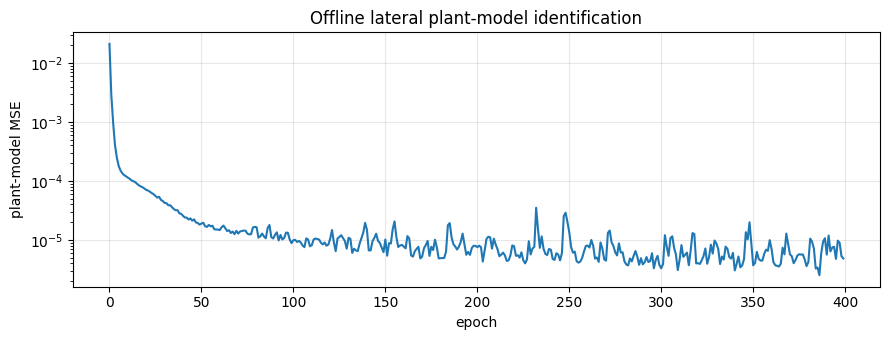

final lateral plant-model MSE: 4.835e-06


In [5]:
cfg = ETDHPConfig(
    actor_hidden=(32, 32),
    critic_hidden=(32, 32),
    model_hidden=(24, 24),
    actor_lr=5e-3,
    critic_lr=5e-3,
    model_lr=5e-3,
    model_epochs=400,
    Q=[200.0, 0.2, 1.0, 50.0, 1.0, 0.5],
    R=[0.5, 0.5],
    gamma=0.95,
    num_epochs_per_trigger=10,
    u_bound=8.0,
    rho=0.05,
    trigger_floor=0.5,
    weight_init_scale=0.3,
    seed=11,
)

agent = ETDHPAgent(
    n_state=6,
    n_control=2,
    state_transform=lateral_state_transform,
    config=cfg,
)

model_losses = agent.fit_plant_model(
    states_arr, actions_arr, next_states_arr,
    batch_size=128,
    verbose=False,
)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.semilogy(model_losses)
ax.set_xlabel("epoch")
ax.set_ylabel("plant-model MSE")
ax.set_title("Offline lateral plant-model identification")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"final lateral plant-model MSE: {model_losses[-1]:.3e}")


## 6. Train lateral ET-DHP under engine failure

The lateral ET-DHP agent is trained on the real single-engine-out scenario for 60-second episodes. That is long enough to learn the steady rudder/aileron compensation, while avoiding unnecessary post-convergence re-training. The final closed-loop evaluation then runs for 300 seconds with the learned lateral actor and the longitudinal trim-hold loop.


ep 1/8: yaw RMSE= 46.246 deg  roll RMSE=192.749 deg  max|psi|=  77.31 deg  max|phi|= 335.56 deg  da= +0.00 deg  dr= +0.01 deg  triggers=207


ep 2/8: yaw RMSE= 13.202 deg  roll RMSE= 49.362 deg  max|psi|=  23.85 deg  max|phi|=  93.34 deg  da= +8.00 deg  dr= +7.98 deg  triggers=301


ep 3/8: yaw RMSE=  0.025 deg  roll RMSE=  0.049 deg  max|psi|=   0.03 deg  max|phi|=   0.06 deg  da= -3.89 deg  dr= -2.26 deg  triggers=1


ep 4/8: yaw RMSE=  0.025 deg  roll RMSE=  0.049 deg  max|psi|=   0.03 deg  max|phi|=   0.06 deg  da= -3.89 deg  dr= -2.26 deg  triggers=1


ep 5/8: yaw RMSE=  0.025 deg  roll RMSE=  0.049 deg  max|psi|=   0.03 deg  max|phi|=   0.06 deg  da= -3.89 deg  dr= -2.26 deg  triggers=1


ep 6/8: yaw RMSE=  0.025 deg  roll RMSE=  0.049 deg  max|psi|=   0.03 deg  max|phi|=   0.06 deg  da= -3.89 deg  dr= -2.26 deg  triggers=1


ep 7/8: yaw RMSE=  0.025 deg  roll RMSE=  0.049 deg  max|psi|=   0.03 deg  max|phi|=   0.06 deg  da= -3.89 deg  dr= -2.26 deg  triggers=1


ep 8/8: yaw RMSE=  0.025 deg  roll RMSE=  0.049 deg  max|psi|=   0.03 deg  max|phi|=   0.06 deg  da= -3.89 deg  dr= -2.26 deg  triggers=1


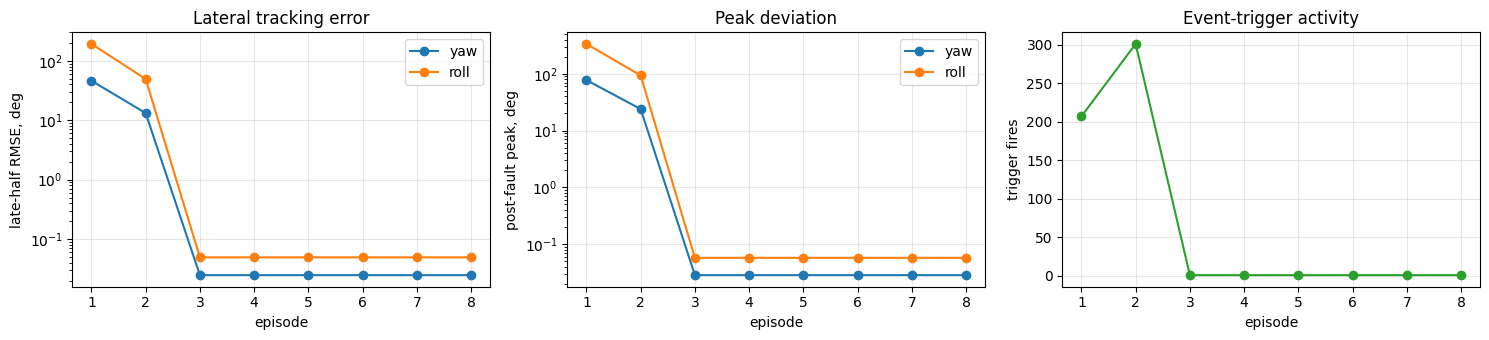

In [6]:
def run_lateral_training_episode(damage_profile, *, learn=True):
    env = make_env(damage_profile=damage_profile, n_steps=N_TRAIN + 5)
    obs, _ = env.reset()
    agent.reset()
    lat_integrals = np.zeros(2, dtype=np.float64)

    psi_log = np.zeros(N_TRAIN)
    phi_log = np.zeros(N_TRAIN)
    da_log = np.zeros(N_TRAIN)
    dr_log = np.zeros(N_TRAIN)
    triggers = 0
    t_axis = np.arange(N_TRAIN) * DT

    for k in range(N_TRAIN - 2):
        agent.predict(obs, lat_integrals, k)
        lateral_cmd = agent.last_action()
        obs, _, _, trunc, _ = env.step(
            compose_action(delta_e_trim_rad, lateral_cmd, throttle_trim)
        )
        lat_integrals = update_lateral_integrals(lat_integrals, obs)

        if learn:
            metrics = agent.learn(obs, lat_integrals, k, dt=DT)
            if metrics["triggered"]:
                triggers += 1

        psi_log[k] = yaw_error_deg(obs)
        phi_log[k] = roll_deg(obs)
        da_log[k] = lateral_cmd[0]
        dr_log[k] = lateral_cmd[1]
        if trunc:
            break

    n = k + 1
    return dict(
        t=t_axis[:n], psi=psi_log[:n], phi=phi_log[:n],
        da=da_log[:n], dr=dr_log[:n], triggers=triggers,
    )


NUM_TRAIN_EPISODES = 8
training_curve = []
for ep in range(NUM_TRAIN_EPISODES):
    train_log = run_lateral_training_episode(LEFT_OUTER_ENGINE_FAILURE, learn=True)
    n2 = len(train_log["psi"]) // 2
    yaw_rmse = float(np.sqrt(np.mean(train_log["psi"][n2:] ** 2)))
    roll_rmse = float(np.sqrt(np.mean(train_log["phi"][n2:] ** 2)))
    yaw_max = float(np.max(np.abs(train_log["psi"][DAMAGE_STEP:])))
    roll_max = float(np.max(np.abs(train_log["phi"][DAMAGE_STEP:])))
    training_curve.append(dict(ep=ep + 1, yaw_rmse=yaw_rmse, roll_rmse=roll_rmse,
                               yaw_max=yaw_max, roll_max=roll_max,
                               triggers=train_log["triggers"]))
    print(f"ep {ep + 1}/{NUM_TRAIN_EPISODES}: "
          f"yaw RMSE={yaw_rmse:7.3f} deg  roll RMSE={roll_rmse:7.3f} deg  "
          f"max|psi|={yaw_max:7.2f} deg  max|phi|={roll_max:7.2f} deg  "
          f"da={train_log['da'][-1]:+6.2f} deg  dr={train_log['dr'][-1]:+6.2f} deg  "
          f"triggers={train_log['triggers']}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
ep_idx = [r["ep"] for r in training_curve]
axes[0].plot(ep_idx, [r["yaw_rmse"] for r in training_curve], "-o", label="yaw")
axes[0].plot(ep_idx, [r["roll_rmse"] for r in training_curve], "-o", label="roll")
axes[0].set_yscale("log")
axes[0].set_xlabel("episode")
axes[0].set_ylabel("late-half RMSE, deg")
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[0].set_title("Lateral tracking error")
axes[1].plot(ep_idx, [r["yaw_max"] for r in training_curve], "-o", label="yaw")
axes[1].plot(ep_idx, [r["roll_max"] for r in training_curve], "-o", label="roll")
axes[1].set_yscale("log")
axes[1].set_xlabel("episode")
axes[1].set_ylabel("post-fault peak, deg")
axes[1].grid(alpha=0.3)
axes[1].legend()
axes[1].set_title("Peak deviation")
axes[2].plot(ep_idx, [r["triggers"] for r in training_curve], "-o", color="tab:green")
axes[2].set_xlabel("episode")
axes[2].set_ylabel("trigger fires")
axes[2].grid(alpha=0.3)
axes[2].set_title("Event-trigger activity")
plt.tight_layout()
plt.show()


## 7. Full closed-loop evaluation

The final run combines the trained lateral ET-DHP actor with the longitudinal trim-hold loop. Lateral ET-DHP weights are frozen here: this cell evaluates the learned controller, it does not continue tuning it.


In [7]:
def run_full_episode(damage_profile):
    env = make_env(damage_profile=damage_profile)
    obs, _ = env.reset()
    agent.reset()
    lat_integrals = np.zeros(2, dtype=np.float64)
    lon_state = {
        "int_v": 0.0,
        "int_h": 0.0,
        "prev_h": altitude_ft(obs),
        "h_dot_f": 0.0,
        "elevator_rad": delta_e_trim_rad,
        "throttle": throttle_trim,
        "throttle_ff": throttle_trim,
        "time": 0.0,
    }

    logs = {name: np.zeros(N_EP) for name in [
        "V", "h", "theta", "psi", "phi",
        "V_actual", "h_actual", "theta_actual", "psi_actual", "phi_actual",
        "V_ref", "h_ref", "theta_ref", "psi_ref", "phi_ref",
        "p", "q", "r", "de", "da", "dr", "throttle",
        "T1", "T2", "T3", "T4", "T_total",
    ]}
    t_axis = np.arange(N_EP) * DT

    for k in range(N_EP - 2):
        lon_state["time"] = k * DT
        elevator_cmd, throttle_cmd, _ = longitudinal_trim_hold(obs, lon_state)
        agent.predict(obs, lat_integrals, k)
        lateral_cmd = agent.last_action()

        obs, _, _, trunc, info = env.step(
            compose_action(elevator_cmd, lateral_cmd, throttle_cmd)
        )
        lat_integrals = update_lateral_integrals(lat_integrals, obs)

        v_actual = true_airspeed_ft_s(obs)
        h_actual = altitude_ft(obs)
        theta_actual = math.degrees(obs[7])
        psi_actual = wrap_deg(math.degrees(obs[8]))
        phi_actual = roll_deg(obs)

        logs["V"][k] = v_actual - V_REF_FT_S
        logs["h"][k] = h_actual - ALT_REF_FT
        logs["theta"][k] = theta_actual - theta_ref_deg
        logs["psi"][k] = wrap_deg(psi_actual - PSI_REF_DEG)
        logs["phi"][k] = phi_actual
        logs["V_actual"][k] = v_actual
        logs["h_actual"][k] = h_actual
        logs["theta_actual"][k] = theta_actual
        logs["psi_actual"][k] = psi_actual
        logs["phi_actual"][k] = phi_actual
        logs["V_ref"][k] = V_REF_FT_S
        logs["h_ref"][k] = ALT_REF_FT
        logs["theta_ref"][k] = theta_ref_deg
        logs["psi_ref"][k] = PSI_REF_DEG
        logs["phi_ref"][k] = 0.0
        logs["p"][k] = math.degrees(obs[3])
        logs["q"][k] = math.degrees(obs[4])
        logs["r"][k] = math.degrees(obs[5])
        logs["de"][k] = math.degrees(elevator_cmd)
        logs["da"][k] = lateral_cmd[0]
        logs["dr"][k] = lateral_cmd[1]
        logs["throttle"][k] = throttle_cmd
        engine_thrust = per_engine_thrust_lb(
            obs, throttle_cmd, engine_mu_from_info(info)
        )
        logs["T1"][k], logs["T2"][k], logs["T3"][k], logs["T4"][k] = engine_thrust
        logs["T_total"][k] = float(np.sum(engine_thrust))
        if trunc:
            break

    n = k + 1
    result = {name: values[:n] for name, values in logs.items()}
    result["t"] = t_axis[:n]
    return result


log = run_full_episode(LEFT_OUTER_ENGINE_FAILURE)
post = slice(DAMAGE_STEP, None)
last_20s = max(1, int(20.0 / DT))
steady = slice(-last_20s, None)

metrics = {
    "speed_peak": float(np.max(np.abs(log["V"][post]))),
    "alt_peak": float(np.max(np.abs(log["h"][post]))),
    "pitch_peak": float(np.max(np.abs(log["theta"][post]))),
    "yaw_peak": float(np.max(np.abs(log["psi"][post]))),
    "roll_peak": float(np.max(np.abs(log["phi"][post]))),
    "speed_rmse": float(np.sqrt(np.mean(log["V"][steady] ** 2))),
    "alt_rmse": float(np.sqrt(np.mean(log["h"][steady] ** 2))),
    "pitch_rmse": float(np.sqrt(np.mean(log["theta"][steady] ** 2))),
    "yaw_rmse": float(np.sqrt(np.mean(log["psi"][steady] ** 2))),
    "roll_rmse": float(np.sqrt(np.mean(log["phi"][steady] ** 2))),
}

spec_ok = (
    metrics["speed_peak"] <= SPEED_HOLD_BAND_FT_S
    and metrics["alt_peak"] <= ALT_HOLD_BAND_FT
    and metrics["pitch_peak"] <= PITCH_HOLD_BAND_DEG
    and metrics["yaw_peak"] <= YAW_HOLD_BAND_DEG
    and metrics["roll_peak"] <= ROLL_HOLD_BAND_DEG
)

print("=== Full engine-out trim-hold evaluation ===")
print(f"Post-fault peak |V - V0|      : {metrics['speed_peak']:7.3f} ft/s")
print(f"Post-fault peak |h - h0|      : {metrics['alt_peak']:7.3f} ft")
print(f"Post-fault peak |theta-theta0|: {metrics['pitch_peak']:7.4f} deg")
print(f"Post-fault peak |psi|         : {metrics['yaw_peak']:7.4f} deg")
print(f"Post-fault peak |phi|         : {metrics['roll_peak']:7.4f} deg")
print(f"Last-20s RMSE V/h/theta/psi/phi   : "
      f"{metrics['speed_rmse']:.3f} ft/s, {metrics['alt_rmse']:.3f} ft, "
      f"{metrics['pitch_rmse']:.4f} deg, {metrics['yaw_rmse']:.4f} deg, "
      f"{metrics['roll_rmse']:.4f} deg")
print(f"Final V error                 : {log['V'][-1]:+.3f} ft/s")
print(f"Final altitude error          : {log['h'][-1]:+.3f} ft")
print(f"Final theta/psi/phi           : {log['theta'][-1]:+.4f}, "
      f"{log['psi'][-1]:+.4f}, {log['phi'][-1]:+.4f} deg")
print(f"Final de/da/dr/throttle       : {log['de'][-1]:+.3f} deg, "
      f"{log['da'][-1]:+.3f} deg, {log['dr'][-1]:+.3f} deg, "
      f"{log['throttle'][-1]:.4f}")
print(f"Final engine thrust T1..T4    : {log['T1'][-1]:.0f}, "
      f"{log['T2'][-1]:.0f}, {log['T3'][-1]:.0f}, "
      f"{log['T4'][-1]:.0f} lb")
print(f"Final references V/h/theta/psi/phi: {V_REF_FT_S:.1f} ft/s, "
      f"{ALT_REF_FT:.1f} ft, {theta_ref_deg:+.3f} deg, "
      f"{PSI_REF_DEG:+.3f} deg, +0.000 deg")
print(f"Full trim-hold spec           : {'PASS' if spec_ok else 'FAIL'}")

assert metrics["speed_peak"] <= SPEED_HOLD_BAND_FT_S
assert metrics["alt_peak"] <= ALT_HOLD_BAND_FT
assert metrics["pitch_peak"] <= PITCH_HOLD_BAND_DEG
assert metrics["yaw_peak"] <= YAW_HOLD_BAND_DEG
assert metrics["roll_peak"] <= ROLL_HOLD_BAND_DEG


=== Full engine-out trim-hold evaluation ===
Post-fault peak |V - V0|      :   0.493 ft/s
Post-fault peak |h - h0|      :   1.380 ft
Post-fault peak |theta-theta0|:  0.0030 deg
Post-fault peak |psi|         :  0.0285 deg
Post-fault peak |phi|         :  0.1027 deg
Last-20s RMSE V/h/theta/psi/phi   : 0.009 ft/s, 0.063 ft, 0.0001 deg, 0.0267 deg, 0.0983 deg
Final V error                 : +0.003 ft/s
Final altitude error          : +0.122 ft
Final theta/psi/phi           : -0.0000, +0.0280, +0.1027 deg
Final de/da/dr/throttle       : -0.722 deg, -3.526 deg, -2.524 deg, 0.7573
Final engine thrust T1..T4    : 0, 14109, 14109, 14109 lb
Final references V/h/theta/psi/phi: 674.0 ft/s, 20000.0 ft, +3.603 deg, +0.000 deg, +0.000 deg
Full trim-hold spec           : PASS


## 8. Visualise the full closed-loop episode


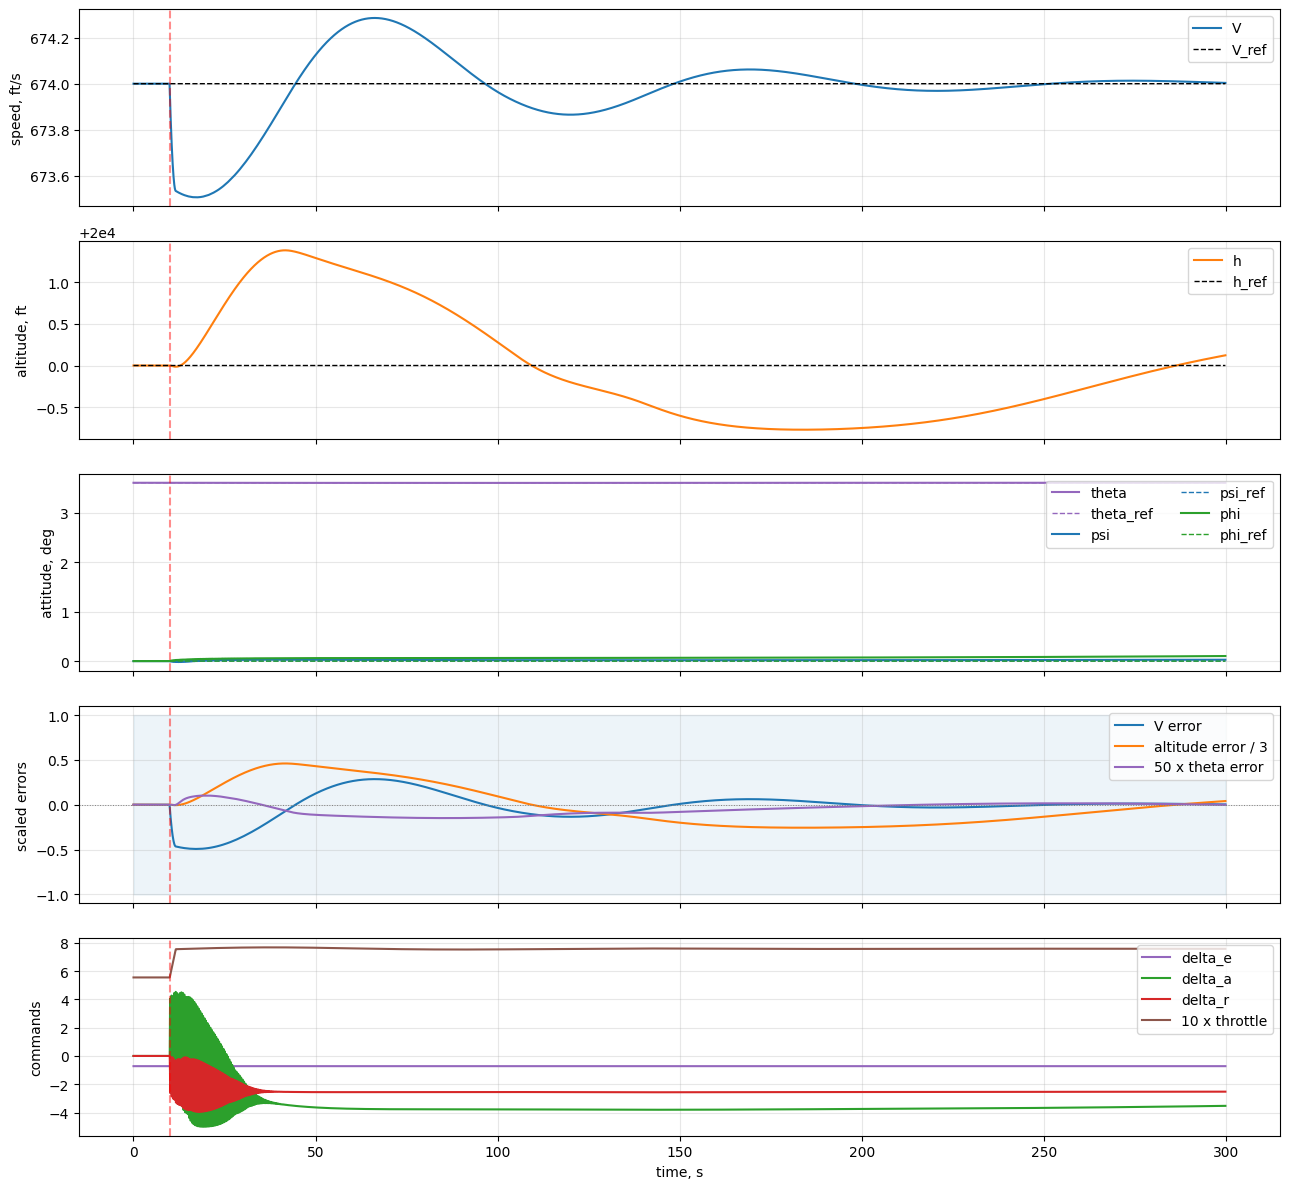

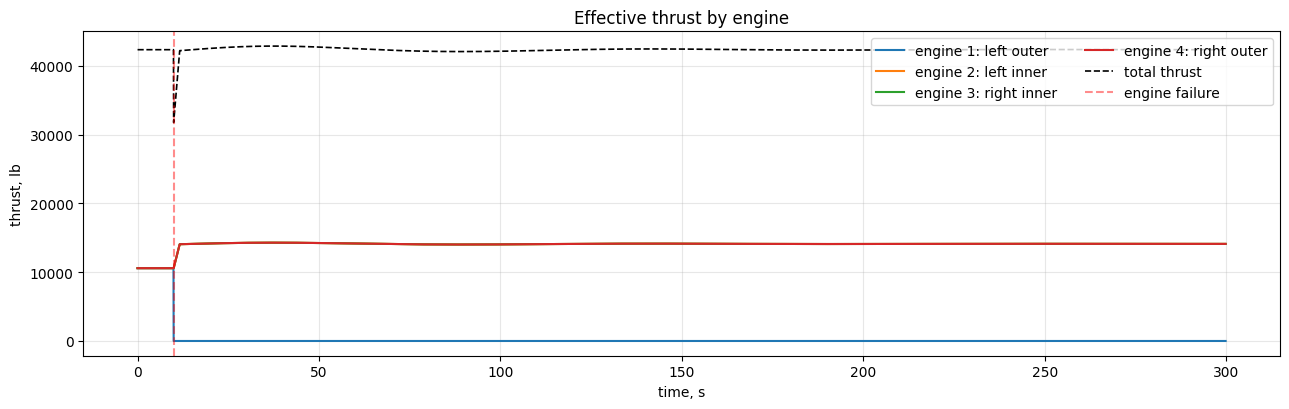

In [8]:
fig, axes = plt.subplots(5, 1, figsize=(13, 12), sharex=True)

axes[0].plot(log["t"], log["V_actual"], color="tab:blue", label="V")
axes[0].plot(log["t"], log["V_ref"], color="black", linestyle="--", linewidth=1.0,
             label="V_ref")
axes[0].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[0].set_ylabel("speed, ft/s")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")

axes[1].plot(log["t"], log["h_actual"], color="tab:orange", label="h")
axes[1].plot(log["t"], log["h_ref"], color="black", linestyle="--", linewidth=1.0,
             label="h_ref")
axes[1].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[1].set_ylabel("altitude, ft")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

axes[2].plot(log["t"], log["theta_actual"], color="tab:purple", label="theta")
axes[2].plot(log["t"], log["theta_ref"], color="tab:purple", linestyle="--", linewidth=1.0,
             label="theta_ref")
axes[2].plot(log["t"], log["psi_actual"], color="tab:blue", label="psi")
axes[2].plot(log["t"], log["psi_ref"], color="tab:blue", linestyle="--", linewidth=1.0,
             label="psi_ref")
axes[2].plot(log["t"], log["phi_actual"], color="tab:green", label="phi")
axes[2].plot(log["t"], log["phi_ref"], color="tab:green", linestyle="--", linewidth=1.0,
             label="phi_ref")
axes[2].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[2].set_ylabel("attitude, deg")
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="upper right", ncol=2)

axes[3].fill_between(log["t"], -SPEED_HOLD_BAND_FT_S, SPEED_HOLD_BAND_FT_S,
                     color="tab:blue", alpha=0.08)
axes[3].plot(log["t"], log["V"], color="tab:blue", label="V error")
axes[3].plot(log["t"], log["h"] / 3.0, color="tab:orange", label="altitude error / 3")
axes[3].plot(log["t"], 50.0 * log["theta"], color="tab:purple", label="50 x theta error")
axes[3].axhline(0.0, color="tab:gray", linestyle=":", linewidth=0.7)
axes[3].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[3].set_ylabel("scaled errors")
axes[3].grid(True, alpha=0.3)
axes[3].legend(loc="upper right")

axes[4].plot(log["t"], log["de"], color="tab:purple", label="delta_e")
axes[4].plot(log["t"], log["da"], color="tab:green", label="delta_a")
axes[4].plot(log["t"], log["dr"], color="tab:red", label="delta_r")
axes[4].plot(log["t"], 10.0 * log["throttle"], color="tab:brown",
             label="10 x throttle")
axes[4].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[4].set_xlabel("time, s")
axes[4].set_ylabel("commands")
axes[4].grid(True, alpha=0.3)
axes[4].legend(loc="upper right")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(13, 4.2))
engine_labels = {
    "T1": "engine 1: left outer",
    "T2": "engine 2: left inner",
    "T3": "engine 3: right inner",
    "T4": "engine 4: right outer",
}
for key, label in engine_labels.items():
    ax.plot(log["t"], log[key], label=label)
ax.plot(log["t"], log["T_total"], color="black", linewidth=1.2,
        linestyle="--", label="total thrust")
ax.axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45,
           label="engine failure")
ax.set_title("Effective thrust by engine")
ax.set_xlabel("time, s")
ax.set_ylabel("thrust, lb")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()


## 9. Comparison: open loop vs. full scheme

Open loop means healthy-trim elevator, zero aileron/rudder and healthy-trim throttle throughout the same engine-failure scenario. This comparison shows the effect of the full control stack, not just the lateral ET-DHP block.


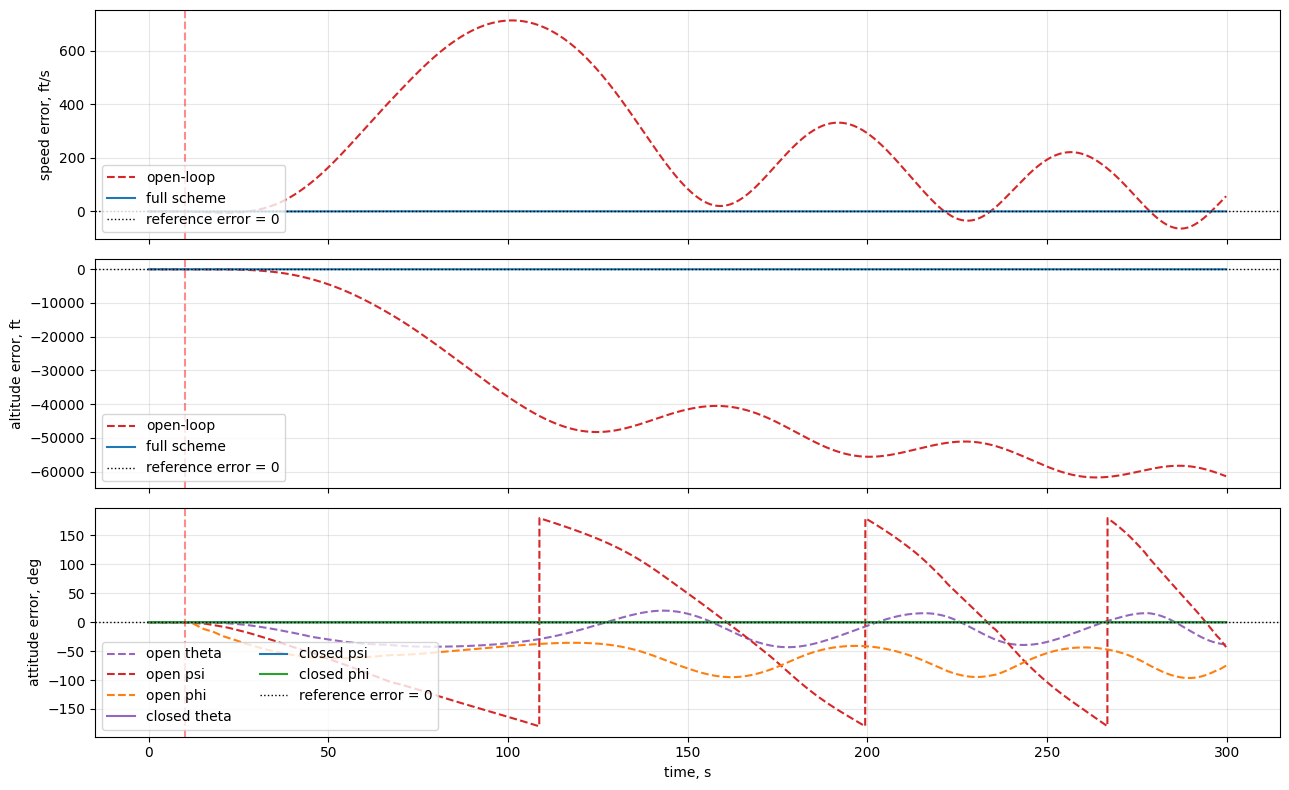

Open-loop @ t=300s: Verr=+56.56 ft/s, herr=-61392.1 ft, theta=-38.36 deg, psi=-43.04 deg, phi=-75.06 deg
Full scheme @ t=300s: Verr=+0.00 ft/s, herr=+0.1 ft, theta=-0.000 deg, psi=+0.028 deg, phi=+0.103 deg


In [9]:
def run_open_loop(damage_profile):
    env = make_env(damage_profile=damage_profile)
    obs, _ = env.reset()
    logs = {name: np.zeros(N_EP) for name in ["V", "h", "theta", "psi", "phi"]}
    neutral_action = compose_action(delta_e_trim_rad, [0.0, 0.0], throttle_trim)
    for k in range(N_EP - 2):
        obs, _, _, trunc, _ = env.step(neutral_action)
        logs["V"][k] = true_airspeed_ft_s(obs) - V_REF_FT_S
        logs["h"][k] = altitude_ft(obs) - ALT_REF_FT
        logs["theta"][k] = pitch_error_deg(obs)
        logs["psi"][k] = yaw_error_deg(obs)
        logs["phi"][k] = roll_deg(obs)
        if trunc:
            break
    n = k + 1
    result = {name: values[:n] for name, values in logs.items()}
    result["t"] = np.arange(n) * DT
    return result


open_log = run_open_loop(LEFT_OUTER_ENGINE_FAILURE)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
axes[0].plot(open_log["t"], open_log["V"], color="tab:red", linestyle="--", label="open-loop")
axes[0].plot(log["t"], log["V"], color="tab:blue", label="full scheme")
axes[0].axhline(0.0, color="black", linestyle=":", linewidth=1.0, label="reference error = 0")
axes[0].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[0].set_ylabel("speed error, ft/s")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="lower left")

axes[1].plot(open_log["t"], open_log["h"], color="tab:red", linestyle="--", label="open-loop")
axes[1].plot(log["t"], log["h"], color="tab:blue", label="full scheme")
axes[1].axhline(0.0, color="black", linestyle=":", linewidth=1.0, label="reference error = 0")
axes[1].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[1].set_ylabel("altitude error, ft")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="lower left")

axes[2].plot(open_log["t"], open_log["theta"], color="tab:purple", linestyle="--", label="open theta")
axes[2].plot(open_log["t"], open_log["psi"], color="tab:red", linestyle="--", label="open psi")
axes[2].plot(open_log["t"], open_log["phi"], color="tab:orange", linestyle="--", label="open phi")
axes[2].plot(log["t"], log["theta"], color="tab:purple", label="closed theta")
axes[2].plot(log["t"], log["psi"], color="tab:blue", label="closed psi")
axes[2].plot(log["t"], log["phi"], color="tab:green", label="closed phi")
axes[2].axhline(0.0, color="black", linestyle=":", linewidth=1.0, label="reference error = 0")
axes[2].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[2].set_xlabel("time, s")
axes[2].set_ylabel("attitude error, deg")
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="lower left", ncol=2)

plt.tight_layout()
plt.show()

print(f"Open-loop @ t={TOTAL_TIME:.0f}s: Verr={open_log['V'][-1]:+.2f} ft/s, "
      f"herr={open_log['h'][-1]:+.1f} ft, theta={open_log['theta'][-1]:+.2f} deg, "
      f"psi={open_log['psi'][-1]:+.2f} deg, phi={open_log['phi'][-1]:+.2f} deg")
print(f"Full scheme @ t={TOTAL_TIME:.0f}s: Verr={log['V'][-1]:+.2f} ft/s, "
      f"herr={log['h'][-1]:+.1f} ft, theta={log['theta'][-1]:+.3f} deg, "
      f"psi={log['psi'][-1]:+.3f} deg, phi={log['phi'][-1]:+.3f} deg")


## 10. Notes for control-system interpretation

* **The lateral fault compensation is learned.** ET-DHP supplies the steady aileron/rudder offsets that cancel the single-engine yaw/roll disturbance. The notebook does not pass engine effectiveness $\mu$ or an analytical allocation matrix to the actor.
* **The longitudinal loop is explicit trim hold.** Elevator and throttle reject the symmetric part of the fault: the loss of total thrust. The loop uses an engine-out throttle feed-forward term, filtered vertical speed, a small altitude integral term, and command rate limits. The feed-forward removes most of the altitude excursion immediately after the thrust loss.
* **Why throttle rises.** At the trim point throttle is about 0.555. With one of four engines failed, the remaining engines need roughly $4/3$ of the previous per-engine thrust. The feed-forward target is slightly above that estimate, and feedback then trims the final throttle near 0.757.
* **Why the final claim uses tolerances.** The fault injects a finite impulse-like disturbance into the closed loop. Exact invariance of $V,h,\theta,\phi,\psi$ at every sample is physically impossible; the meaningful requirement is bounded deviation and recovery inside engineering bands.
* **If a pure ET-DHP-only architecture is required.** The next step would be replacing the longitudinal trim-hold loop by a second ET-DHP agent for $[V,h,\theta,q] \to [\delta_e,\delta_T]$. In this model that needs additional stabilisation/tuning because the longitudinal ET-DHP update is much more sensitive than the lateral FTC task.

* **Engine-thrust plot.** The thrust figure logs effective per-engine thrust from the same JT9D model used by the nonlinear plant. After $t=10$ s, engine #1 has $\mu_1=0$, while engines #2-#4 rise with throttle feed-forward and feedback.
